In [1]:
import firebase_admin
from firebase_admin import credentials
from firebase_admin import firestore
import torch

cred = credentials.Certificate('adminKey.json')
firebase_admin.initialize_app(cred)
db = firestore.client()


In [2]:
include_people = ['Ethan Shao', 'Jerry', 'Joley', 'Lillian', 'Ren', 'Sophia', 'Stephen', 'Yuanheng']
include_activities = ['walk', 'jump', 'run', 'sit', 'upstair', 'downstair']


In [3]:
from torch.utils.data import Dataset
import numpy as np
import scipy.signal as signal
import ast

class AccelerometerDataset(Dataset):
    def __init__(self,
                 collection: str,
                 include_people: list[str],
                 include_activities: list[str],
                 load_from_cache: bool = False,
                 use_high_pass_filter: bool = True,
                 use_low_pass_filter: bool = True,
                 use_z_score_normalization: bool = True,
                 ):
        """
        Load accelerometer time-series data from Firestore to integrate with DataLoader.

        :param collection: A string that determines whether to load from "training" or "testing" collection.
        :param include_people: Include data from people in the list.
        :param include_activities: Include data from activities in the list.
        :param load_from_cache: If true, will load last cached data, skip fetching from Firestore, and ignore include_people and include_activities. Otherwise, fetch from Firebase according to what to include and cache data as txt.
        :param use_high_pass_filter: If true, high pass filtering is applied to remove gravity vector from data.
        :param use_low_pass_filter: If true, low pass filter is applied to remove vibrations vector from data.
        :param use_z_score_normalization: If true, z_score normalization is applied to data to ensure consistency across sensors, motion intensity between people etc.
        """
        self.collection = collection
        self.include_people = include_people
        self.include_activities = include_activities
        self.load_from_cache = load_from_cache
        self.use_high_pass_filter = use_high_pass_filter
        self.use_low_pass_filter = use_low_pass_filter
        self.use_z_score_normalization = use_z_score_normalization

        # data is a 3D array
        # Outside arrays are 2-second chunk measurements
        # Middle arrays are individual measurements during the 2 seconds
        # Inner arrays are [x, y, z] component of measurement
        self.data = []

        # label is a 1D array.
        # Stores the activity type, corresponding to each item in data array
        self.labels = []


        if load_from_cache:
            with open(f'{collection}.txt', 'r') as f:
                self.data = ast.literal_eval(f.readline())
                self.labels = ast.literal_eval(f.readline())

        else:
            # begin loading data from firestore
            for person in db.collection(collection).stream():
                person = str(person.to_dict()['name'])
                if person not in include_people:
                    continue

                for index, activity in enumerate(include_activities):
                    for record in db.collection(collection).document(person).collection(activity).stream():
                        record = record.to_dict()

                        # take data from first 3 seconds to last 3 seconds
                        accelerations = record['acceleration'][300:-300]

                        # split into 2 second chunks
                        for i in range(0, len(accelerations) // 200):
                            self.data.append([[measurement['x'], measurement['y'], measurement['z']] for measurement in accelerations[i*200:(i+1)*200]])

                            # use index as the activity encoding for labels
                            self.labels.append(index)

            # cache the results
            with open(f'{collection}.txt', 'w+') as f:
                f.write(str(self.data))
                f.write('\n')
                f.write(str(self.labels))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        processed_data = np.array(self.data[index])

        if self.use_high_pass_filter:
            processed_data = self.high_pass_filter(processed_data)

        if self.use_low_pass_filter:
            processed_data = self.low_pass_filter(processed_data)

        if self.use_z_score_normalization:
            processed_data = self.z_score_normalization(processed_data)

        return processed_data, self.labels[index]

    def high_pass_filter(self, data, cutoff=0.5, fs=100, order=2):
        """
        Applies a high-pass Butterworth filter to remove gravity components from data.

        :param data: 2D array of shape (N, 3) where each column is X, Y, Z acceleration.
        :param cutoff: Cutoff frequency in Hz (default = 0.5Hz).
        :param fs: Sampling frequency in Hz (default = 100Hz).
        :param order: Order of the Butterworth filter (default = 2).
        :return: Filtered acceleration data of shape (N, 3).
        """

        nyquist = 0.5 * fs  # Nyquist frequency
        normal_cutoff = cutoff / nyquist  # Normalize cutoff freq

        # Design Butterworth high-pass filter in SOS format
        sos = signal.butter(order, normal_cutoff, btype='high', analog=False, output='sos')

        # Apply filter to each axis (X, Y, Z)
        filtered_data = np.zeros_like(data)
        for i in range(3):  # Apply filter to each axis separately
            filtered_data[:, i] = signal.sosfiltfilt(sos, data[:, i])

        return filtered_data

    def low_pass_filter(self, data, cutoff=10, fs=100, order=2):
        """
        Applies a low-pass Butterworth filter to remove gravity components from data.

        :param data: 2D array of shape (N, 3) where each column is X, Y, Z acceleration.
        :param cutoff: Cutoff frequency in Hz (default = 10Hz).
        :param fs: Sampling frequency in Hz (default = 100Hz).
        :param order: Order of the Butterworth filter (default = 2).
        :return: Filtered acceleration data of shape (N, 3).
        """

        nyquist = 0.5 * fs  # Nyquist frequency
        normal_cutoff = cutoff / nyquist  # Normalize cutoff freq

        # Design Butterworth high-pass filter in SOS format
        sos = signal.butter(order, normal_cutoff, btype='low', analog=False, output='sos')

        # Apply filter to each axis (X, Y, Z)
        filtered_data = np.zeros_like(data)
        for i in range(3):  # Apply filter to each axis separately
            filtered_data[:, i] = signal.sosfiltfilt(sos, data[:, i])

        return filtered_data

    def z_score_normalization(self, data):
        mean, std = np.mean(data, axis=0), np.std(data, axis=0) + 1e-9
        return (data - mean) / std


In [4]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes=len(include_activities)):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv1d(in_channels=3, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(64)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(128)

        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.global_avg_pool(x).squeeze(-1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [5]:
class CNN_LSTM_Model(nn.Module):
    def __init__(self, num_classes=len(include_activities), input_size=3, hidden_size=64, num_layers=2, dropout=0.3):
        """
        CNN + LSTM model for accelerometer-based activity recognition.

        :param num_classes: Number of activity classes.
        :param input_size: Number of input features (3 for x, y, z acceleration).
        :param hidden_size: LSTM hidden state size.
        :param num_layers: Number of LSTM layers.
        :param dropout: Dropout rate for regularization.
        """
        super(CNN_LSTM_Model, self).__init__()

        # 1D CNN Layers for feature extraction
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, stride=1, padding=2)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

        # LSTM for temporal modeling
        self.lstm = nn.LSTM(input_size=128, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout, bidirectional=True)

        # Fully Connected Layer
        self.fc = nn.Linear(hidden_size * 2, num_classes)  # *2 for bidirectional LSTM

    def forward(self, x):
        """
        Forward pass through the CNN + LSTM network.

        :param x: Input tensor of shape (batch_size, seq_len, 3)
        :return: Logits for classification
        """
        # Reshape: (batch_size, seq_len, 3) → (batch_size, 3, seq_len) for CNN
        x = x.permute(0, 2, 1)

        # Apply CNN layers
        x = self.pool(self.relu(self.conv1(x)))  # (batch, 32, seq_len/2)
        x = self.pool(self.relu(self.conv2(x)))  # (batch, 64, seq_len/4)
        x = self.pool(self.relu(self.conv3(x)))  # (batch, 128, seq_len/8)

        # Reshape for LSTM: (batch_size, 128, seq_len/8) → (batch_size, seq_len/8, 128)
        x = x.permute(0, 2, 1)

        # LSTM layer
        lstm_out, _ = self.lstm(x)  # (batch_size, seq_len/8, hidden_size * 2)

        # Take only the last time step's output
        x = lstm_out[:, -1, :]  # (batch_size, hidden_size * 2)

        # Fully connected layer
        x = self.fc(x)

        return x

### Change `load_from_cache` to True if fetching the same data. This saves Firebase reads and time.

In [6]:
from torch.utils.data import DataLoader

train_dataset = AccelerometerDataset(collection='training', include_people=include_people, include_activities=include_activities, load_from_cache=False)
test_dataset = AccelerometerDataset(collection='testing', include_people=include_people, include_activities=include_activities, load_from_cache=False)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_loop(num_epochs=20):
    model.train()

    for epoch in range(num_epochs):
        total_loss = 0
        for batch in train_dataloader:
            inputs, labels = batch[0].to(device), batch[1].to(device)

            # Reshape input: (batch_size, seq_len, 3) → (batch_size, 3, seq_len)
            inputs = inputs.permute(0, 2, 1).float()

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_dataloader):.4f}")

def test_loop():
    model.eval()

    # count the precision and build confusion matrix
    correct = 0
    total = 0
    loss_total = 0
    all_preds = np.array([])
    all_labels = np.array([])

    with torch.no_grad():  # Disable gradient computation for faster inference
        for batch in test_dataloader:
            inputs, labels = batch
            inputs, labels = inputs.to(device), labels.to(device)

            # Reshape input: (batch_size, seq_len, 3) → (batch_size, 3, seq_len)
            inputs = inputs.permute(0, 2, 1).float()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss_total += loss.item()

            # Get predicted class with the highest probability
            _, predicted = torch.max(outputs, 1)

            # Update correct predictions and total samples
            all_preds = np.append(all_preds, predicted.cpu().numpy())
            all_labels = np.append(all_labels, labels.cpu().numpy())
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    # Calculate metrics
    accuracy = 100 * correct / total
    avg_loss = loss_total / len(test_dataloader)

    all_preds = all_preds.flatten()
    all_labels = all_labels.flatten()

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=include_activities)
    disp.plot(cmap='Blues')
    plt.grid(False)
    plt.show()

    print(f'Test Loss: {avg_loss:.4f}, Test Accuracy: {correct}/{total}, {accuracy:.2f}%')

    return accuracy

In [8]:
lstm = CNN_LSTM_Model().to(device)
optimizer2 = torch.optim.Adam(lstm.parameters(), lr=0.001)

def train_loop_lstm(num_epochs=20):
    lstm.train()

    for epoch in range(num_epochs):
        total_loss = 0
        for batch in train_dataloader:
            inputs, labels = batch[0].to(device), batch[1].to(device)

            # Reshape input: (batch_size, seq_len, 3) → (batch_size, 3, seq_len)
            inputs = inputs.float()

            optimizer2.zero_grad()
            outputs = lstm(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer2.step()
            total_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_dataloader):.4f}")

def test_loop_lstm():
    lstm.eval()

    # count the precision and build confusion matrix
    correct = 0
    total = 0
    loss_total = 0
    all_preds = np.array([])
    all_labels = np.array([])

    with torch.no_grad():  # Disable gradient computation for faster inference
        for batch in test_dataloader:
            inputs, labels = batch
            inputs, labels = inputs.to(device), labels.to(device)

            # Reshape input: (batch_size, seq_len, 3) → (batch_size, 3, seq_len)
            inputs = inputs.float()

            outputs = lstm(inputs)
            loss = criterion(outputs, labels)
            loss_total += loss.item()

            # Get predicted class with highest probability
            _, predicted = torch.max(outputs, 1)

            # Update correct predictions and total samples
            all_preds = np.append(all_preds, predicted.cpu().numpy())
            all_labels = np.append(all_labels, labels.cpu().numpy())
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    # Calculate metrics
    accuracy = 100 * correct / total
    avg_loss = loss_total / len(test_dataloader)

    all_preds = all_preds.flatten()
    all_labels = all_labels.flatten()

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=include_activities)
    disp.plot(cmap='Blues')
    plt.grid(False)
    plt.show()

    print(f'Test Loss: {avg_loss:.4f}, Test Accuracy: {correct}/{total}, {accuracy:.2f}%')

    return accuracy

In [9]:
train_loop(20)

Epoch [1/20], Loss: 1.6060
Epoch [2/20], Loss: 1.2763
Epoch [3/20], Loss: 1.0904
Epoch [4/20], Loss: 0.9662
Epoch [5/20], Loss: 0.8572
Epoch [6/20], Loss: 0.7933
Epoch [7/20], Loss: 0.7101
Epoch [8/20], Loss: 0.7257
Epoch [9/20], Loss: 0.6559
Epoch [10/20], Loss: 0.5845
Epoch [11/20], Loss: 0.5892
Epoch [12/20], Loss: 0.5296
Epoch [13/20], Loss: 0.5484
Epoch [14/20], Loss: 0.5257
Epoch [15/20], Loss: 0.4764
Epoch [16/20], Loss: 0.4318
Epoch [17/20], Loss: 0.4141
Epoch [18/20], Loss: 0.4214
Epoch [19/20], Loss: 0.4319
Epoch [20/20], Loss: 0.4075


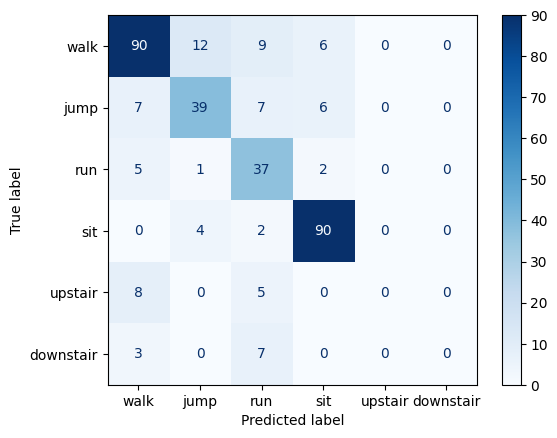

Test Loss: 0.7491, Test Accuracy: 256/340, 75.29%


75.29411764705883

In [10]:
test_loop()

In [11]:
train_loop_lstm(25)

Epoch [1/25], Loss: 1.6815
Epoch [2/25], Loss: 1.5765
Epoch [3/25], Loss: 1.5357
Epoch [4/25], Loss: 1.5370
Epoch [5/25], Loss: 1.5259
Epoch [6/25], Loss: 1.4673
Epoch [7/25], Loss: 1.4019
Epoch [8/25], Loss: 1.2680
Epoch [9/25], Loss: 1.1370
Epoch [10/25], Loss: 1.0129
Epoch [11/25], Loss: 0.8646
Epoch [12/25], Loss: 0.8392
Epoch [13/25], Loss: 0.7425
Epoch [14/25], Loss: 0.6993
Epoch [15/25], Loss: 0.7625
Epoch [16/25], Loss: 0.8048
Epoch [17/25], Loss: 0.6817
Epoch [18/25], Loss: 0.5814
Epoch [19/25], Loss: 0.5427
Epoch [20/25], Loss: 0.5398
Epoch [21/25], Loss: 0.4794
Epoch [22/25], Loss: 0.5093
Epoch [23/25], Loss: 0.4880
Epoch [24/25], Loss: 0.5053
Epoch [25/25], Loss: 0.4849


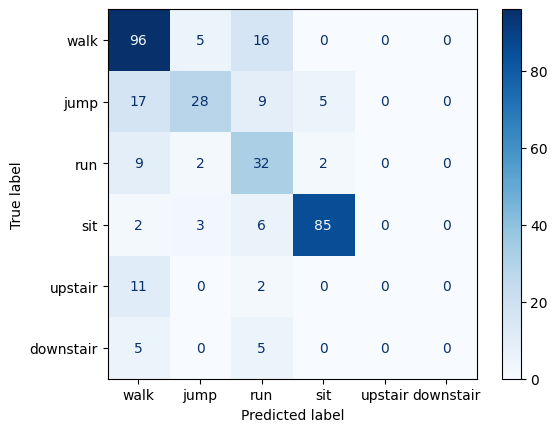

Test Loss: 0.9866, Test Accuracy: 241/340, 70.88%


70.88235294117646

In [12]:
test_loop_lstm()